In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import calendar
df = pd.read_csv('California_Historic_Fire_Perimeters.csv')

   OBJECTID    Year State Agency Unit ID  Fire Name Local Incident Number  \
0         1  2025.0    CA    CDF     LDF  PALISADES              00000738   
1         2  2025.0    CA    CDF     LAC      EATON              00009087   
2         3  2025.0    CA    CDF     ANF     HUGHES              00250270   
3         4  2025.0    CA    CCO     VNC    KENNETH              00003155   
4         5  2025.0    CA    CDF     LDF      HURST              00003294   

             Alarm Date      Containment Date  Cause  ...  \
0   1/7/2025 8:00:00 AM  1/31/2025 8:00:00 AM     14  ...   
1   1/8/2025 8:00:00 AM  1/31/2025 8:00:00 AM     14  ...   
2  1/22/2025 8:00:00 AM  1/28/2025 8:00:00 AM     14  ...   
3   1/9/2025 8:00:00 AM   2/4/2025 8:00:00 AM     14  ...   
4   1/7/2025 8:00:00 AM   1/9/2025 8:00:00 AM     14  ...   

   Management Objective  GIS Calculated Acres           Comments Complex Name  \
0                   1.0            23448.8800                NaN          NaN   
1       

In [37]:
print(df.head())
print(list(df.columns))

print(df.describe())


   OBJECTID  Year State Agency Unit ID  Fire Name Local Incident Number  \
0         1  2025    CA    CDF     LDF  PALISADES              00000738   
1         2  2025    CA    CDF     LAC      EATON              00009087   
2         3  2025    CA    CDF     ANF     HUGHES              00250270   
3         4  2025    CA    CCO     VNC    KENNETH              00003155   
4         5  2025    CA    CDF     LDF      HURST              00003294   

           Alarm Date    Containment Date  Cause  ...  \
0 2025-01-07 08:00:00 2025-01-31 08:00:00     14  ...   
1 2025-01-08 08:00:00 2025-01-31 08:00:00     14  ...   
2 2025-01-22 08:00:00 2025-01-28 08:00:00     14  ...   
3 2025-01-09 08:00:00 2025-02-04 08:00:00     14  ...   
4 2025-01-07 08:00:00 2025-01-09 08:00:00     14  ...   

                                 IRWIN ID  Fire Number (historical use)  \
0  {A7EA5D21-F882-44B8-BF64-44AB11059DC1}                           NaN   
1  {72660ADC-B5EF-4D96-A33F-B4EA3740A4E3}               

In [14]:
# Convert date columns to datetime format
# Create new column "Fire Duration" as diff in days between "Containment Date" and "Alarm Date"

df["Alarm Date"] = pd.to_datetime(df["Alarm Date"])
df["Containment Date"] = pd.to_datetime(df["Containment Date"])

df["Fire Duration"] = (df["Containment Date"] - df["Alarm Date"]).dt.days

print(df[["Fire Name", "Fire Duration"]].head())

max_duration = df["Fire Duration"].max()
# print("Maximum fire duration:", max_duration)
# print(df["Fire Duration"].describe())

outlier_row = df.loc[df["Fire Duration"].idxmax()]
print(outlier_row)

   Fire Name  Fire Duration
0  PALISADES           24.0
1      EATON           23.0
2     HUGHES            6.0
3    KENNETH           26.0
4      HURST            2.0
OBJECTID                                      10233
Year                                         1990.0
State                                            CA
Agency                                          NPS
Unit ID                                         YNP
Fire Name                                     PIUTE
Local Incident Number                      00000086
Alarm Date                      1990-08-13 07:00:00
Containment Date                1999-09-14 07:00:00
Cause                                             1
Collection Method                               4.0
Management Objective                            1.0
GIS Calculated Acres                       552.4727
Comments                                        NaN
Complex Name                                    NaN
IRWIN ID                                        NaN


In [15]:
# Check for negative fire durations, and remove
neg_durations = df[df["Fire Duration"] < 0]
print(neg_durations)
df = df[df["Fire Duration"] >= 0]

       OBJECTID    Year State Agency Unit ID Fire Name Local Incident Number  \
2941       2943  2017.0    CA    USF     PNF  SQUIRREL              00001273   
3925       3927  2015.0    CA    CCO     VNC      PALM              00016943   
3976       3978  2015.0    CA    CCO     VNC    PERKIN                053255   
4731       4733  2012.0    CA    LRA     LAC  HILLSIDE              00003279   
4807       4809  2012.0    CA    USF     SNF    SUMMIT              00000002   
6887       6889  2005.0    CA    CCO     LAC    SIERRA              00149034   
6976       6978  2005.0    CA    USF     BDF    BARTON              00000000   
7007       7009  2005.0    CA    USF     STF  HIGHLAND                   NaN   
7034       7036  2005.0    CA    USF     LNF     ROCKY              00000000   
7328       7330  2004.0    CA    USF     TNF    LOWELL              00000000   
8612       8614  1999.0    CA    USF     ENF      JAKE              00000000   
12996     12998  1978.0    CA    USF    

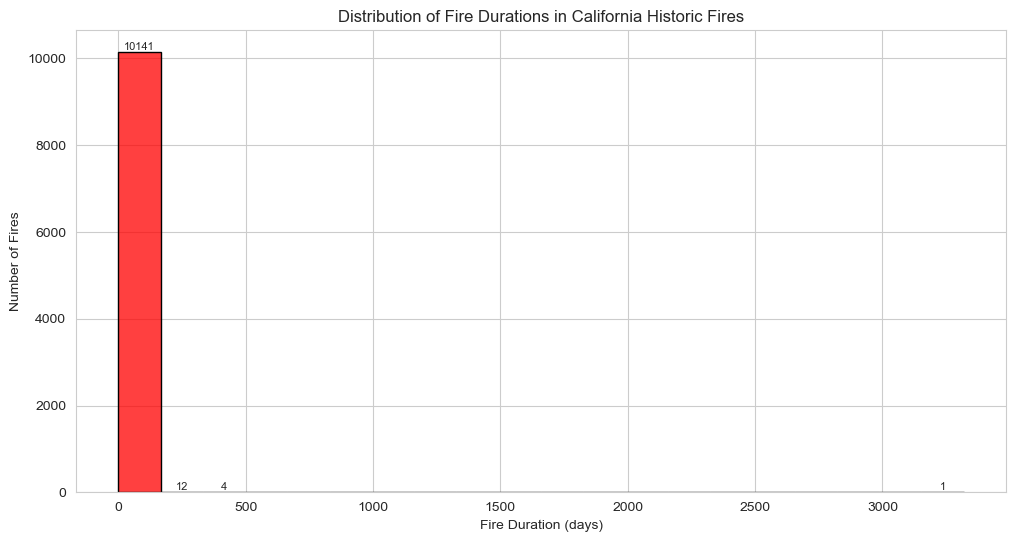

Counts per bin: [np.int64(10141), np.int64(12), np.int64(4), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


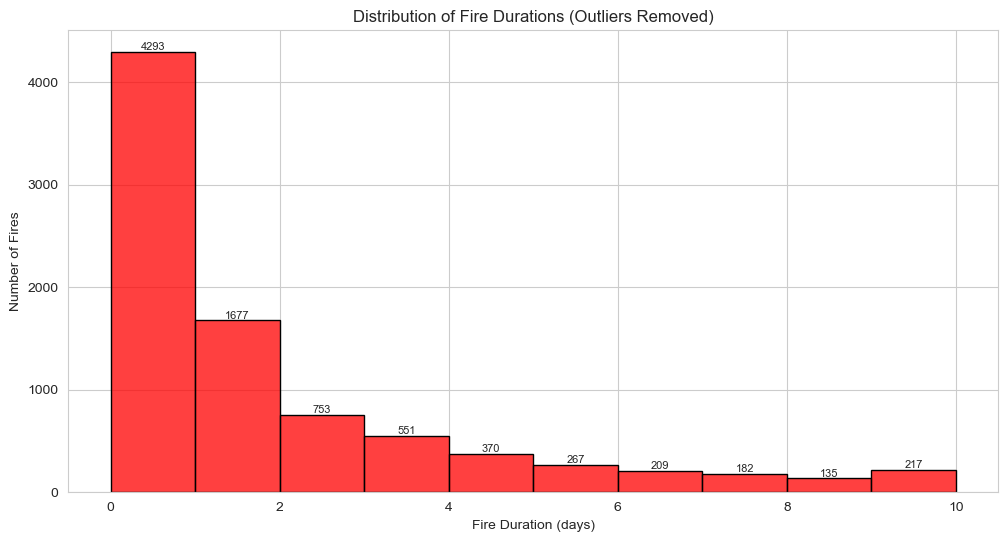

Counts per bin: [np.int64(4293), np.int64(1677), np.int64(753), np.int64(551), np.int64(370), np.int64(267), np.int64(209), np.int64(182), np.int64(135), np.int64(217)]


In [22]:
# Plot histogram of fire durations
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))  
ax = sns.histplot(data=df, x="Fire Duration", bins=20, kde=False, color='red', edgecolor="black")

plt.title("Distribution of Fire Durations in California Historic Fires")
plt.xlabel("Fire Duration (days)")
plt.ylabel("Number of Fires")

# Label bins with more than 1 datapoint
for patch in ax.patches:
    count = patch.get_height()
    if count >= 1:
        x = patch.get_x() + patch.get_width() / 2  # center of the bar
        y = count
        ax.text(x, y, str(int(count)), ha='center', va='bottom', fontsize=8)

plt.show()

# Optional: print counts
counts = [patch.get_height() for patch in ax.patches]
print("Counts per bin:", counts)




# Plot histogram of fire durations without outlier
sns.set_style("whitegrid")

# Calculate IQR
Q1 = df["Fire Duration"].quantile(0.25)
Q3 = df["Fire Duration"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
filtered_df = df[(df["Fire Duration"] >= lower_bound) & (df["Fire Duration"] <= upper_bound)]

plt.figure(figsize=(12, 6))

# Plot histogram
ax = sns.histplot(
    data=filtered_df,
    x="Fire Duration",
    binwidth=1,
    bins=20,
    kde=False,
    color="red",
    edgecolor="black"
)

plt.title("Distribution of Fire Durations (Outliers Removed)")
plt.xlabel("Fire Duration (days)")
plt.ylabel("Number of Fires")

# Label bins with more than 1 datapoint
for patch in ax.patches:
    count = patch.get_height()
    if count >= 1:
        x = patch.get_x() + patch.get_width() / 2
        y = count
        ax.text(x, y, str(int(count)), ha='center', va='bottom', fontsize=8)

plt.show()

# Optional: print counts for verification
counts = [patch.get_height() for patch in ax.patches]
print("Counts per bin:", counts)

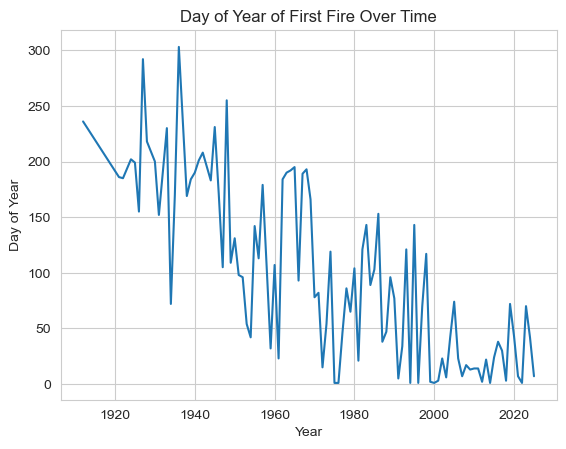

In [23]:
# line plot of first fire each year

df["Alarm Date"] = pd.to_datetime(df["Alarm Date"])
first_fire = df.groupby(df["Alarm Date"].dt.year)["Alarm Date"].min()

first_fire.dt.dayofyear.plot(kind="line")
plt.title("Day of Year of First Fire Over Time")
plt.ylabel("Day of Year")
plt.xlabel("Year")
plt.show()

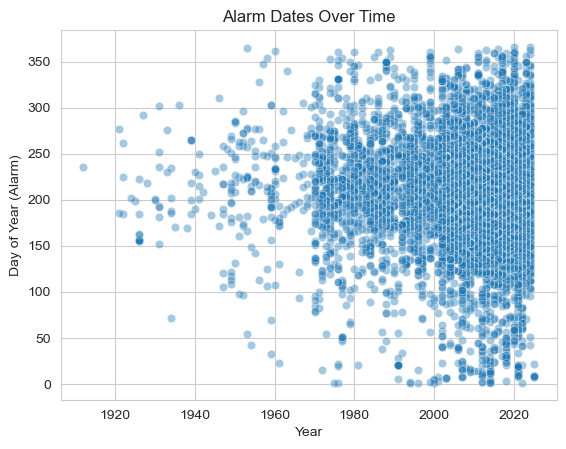

In [ ]:
# Scatterplot of all alarm dates
df["Year"] = df["Alarm Date"].dt.year
df["DOY"] = df["Alarm Date"].dt.dayofyear

sns.scatterplot(data=df, x="Year", y="DOY", alpha=0.4)
plt.title("Alarm Dates Over Time")
plt.ylabel("Day of Year (Alarm)")
plt.xlabel("Year")
plt.show()

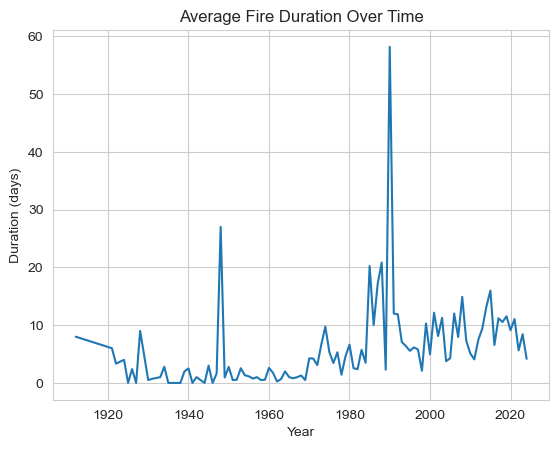

In [ ]:
# Line plot of average fire duration each year
avg_duration = df.groupby(df["Alarm Date"].dt.year)["Fire Duration"].mean()

avg_duration.plot(kind="line")
plt.title("Average Fire Duration Over Time")
plt.ylabel("Duration (days)")
plt.xlabel("Year")
plt.show()

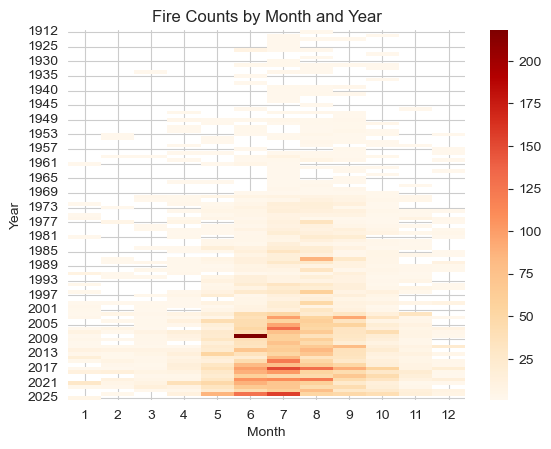

In [ ]:
# heatmap of fire counts by month and year
df["Year"] = df["Alarm Date"].dt.year
df["Month"] = df["Alarm Date"].dt.month

pivot = df.pivot_table(index="Year", columns="Month", values="Fire Duration", aggfunc="count")

sns.heatmap(pivot, cmap="OrRd")
plt.title("Fire Counts by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

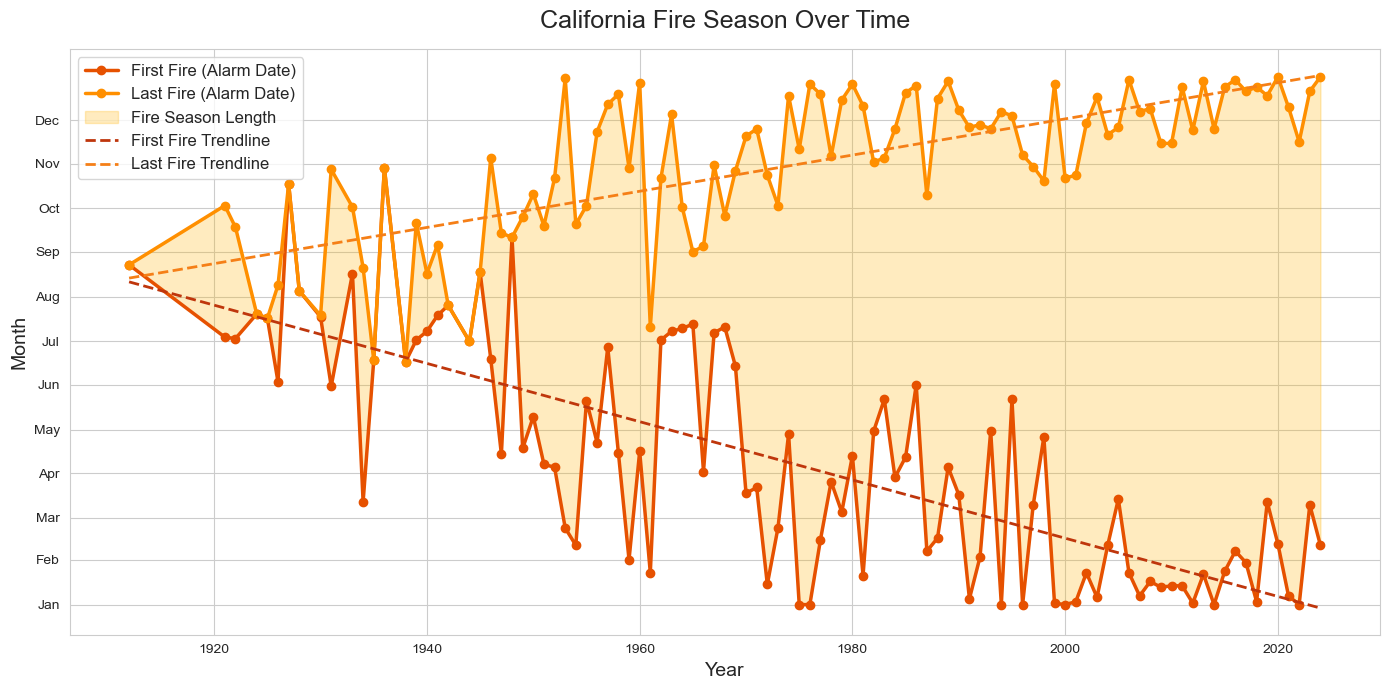

In [ ]:
# dual time plot for first and last fire dates each year

# Ensure alarm dates are datetime
df["Alarm Date"] = pd.to_datetime(df["Alarm Date"])
df["Year"] = df["Alarm Date"].dt.year

# Exclude incomplete 2025 data
df_filtered = df[df["Year"] != 2025]

# First and last alarm date per year (in day-of-year)
first_fire = df_filtered.groupby("Year")["Alarm Date"].min().dt.dayofyear
last_fire  = df_filtered.groupby("Year")["Alarm Date"].max().dt.dayofyear

# Prepare for regression
years = first_fire.index.values
first_vals = first_fire.values
last_vals  = last_fire.values

# Trendlines
m_first, b_first = np.polyfit(years, first_vals, 1)
first_trend = m_first * years + b_first

m_last, b_last = np.polyfit(years, last_vals, 1)
last_trend = m_last * years + b_last

# plot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

plt.plot(years, first_vals, marker="o", linewidth=2.5,
         label="First Fire (Alarm Date)", color="#E65100")

plt.plot(years, last_vals, marker="o", linewidth=2.5,
         label="Last Fire (Alarm Date)", color="#FF8F00")

plt.fill_between(years, first_vals, last_vals,
                 color="#FFB300", alpha=0.25, label="Fire Season Length")

# Trendlines
plt.plot(years, first_trend, "--", linewidth=2, color="#BF360C",
         label="First Fire Trendline")
plt.plot(years, last_trend, "--", linewidth=2, color="#F57F17",
         label="Last Fire Trendline")


# Create ticks at the first of each month (DOY)
month_starts = [pd.Timestamp(f"2024-{m:02d}-01").dayofyear for m in range(1, 13)]
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

plt.yticks(month_starts, month_labels)

plt.title("California Fire Season Over Time",
          fontsize=18, pad=15)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Month", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


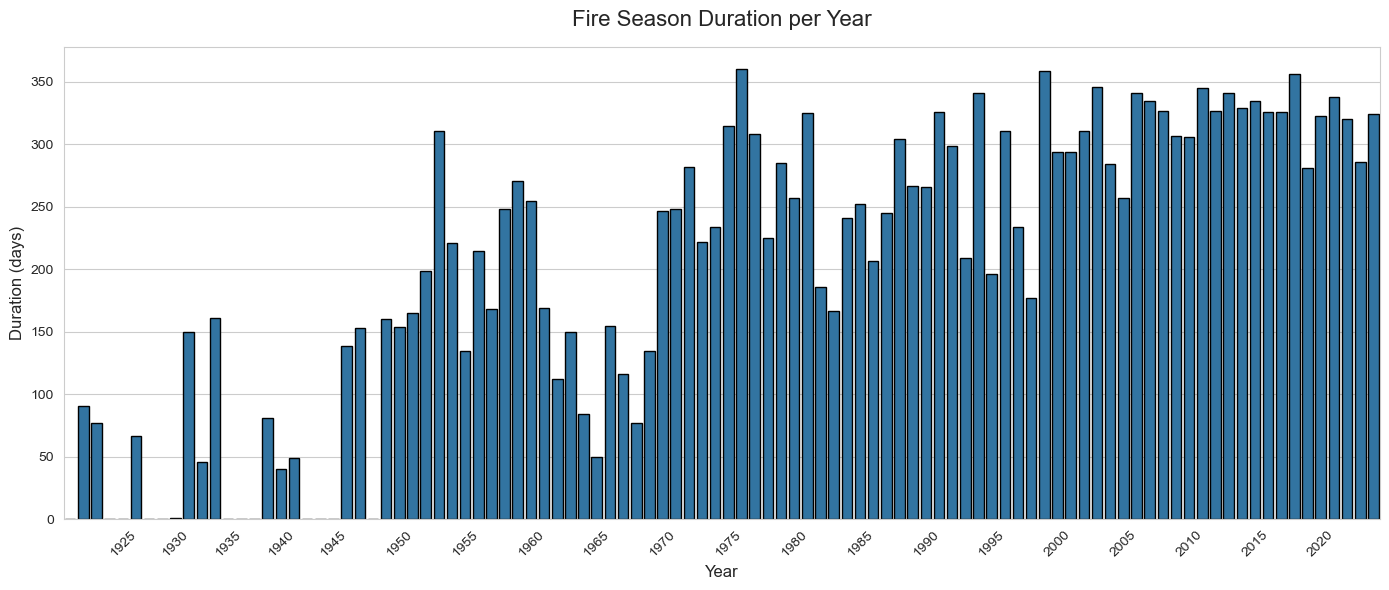

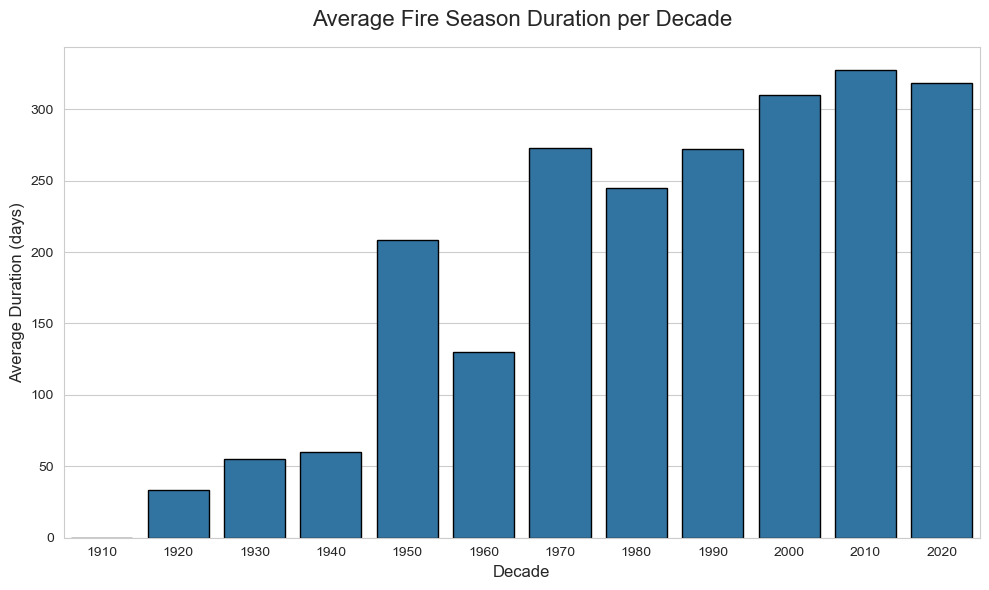

In [ ]:
# bar plots of fire season duration per year and per decade

# Ensure alarm dates are datetime
df["Alarm Date"] = pd.to_datetime(df["Alarm Date"])

# Extract year
df["Year"] = df["Alarm Date"].dt.year

# Exclude 2025 (incomplete data)
df_filtered = df[df["Year"] != 2025]

# First and last alarm date per year
first_fire = df_filtered.groupby("Year")["Alarm Date"].min()
last_fire  = df_filtered.groupby("Year")["Alarm Date"].max()

# Fire season duration per year in days
season_duration = (last_fire - first_fire).dt.days
season_duration_df = season_duration.reset_index()
season_duration_df.columns = ["Year", "Duration"]

# Plot 1: Fire season duration per year
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

sns.barplot(x="Year", y="Duration", data=season_duration_df, edgecolor="black")

plt.title("Fire Season Duration per Year", fontsize=16, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Duration (days)", fontsize=12)

# Only label every 5th year for readability
years = season_duration_df["Year"].values
plt.xticks(
    ticks=range(len(years)),
    labels=[year if year % 5 == 0 else "" for year in years],
    rotation=45
)

plt.tight_layout()
plt.show()

# Plot 2: Average fire season duration per decade
# Calculate decade
season_duration_df["Decade"] = (season_duration_df["Year"] // 10) * 10

avg_decade_duration = season_duration_df.groupby("Decade")["Duration"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x="Decade", y="Duration", data=avg_decade_duration, edgecolor="black")

plt.title("Average Fire Season Duration per Decade", fontsize=16, pad=15)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Average Duration (days)", fontsize=12)
plt.tight_layout()
plt.show()
